# Data to be fetched from the ENTSO-E Transparency Platform

**All data and variables fetched from ENTSO-E TP are explained in the [ENTSO-E data overview](./01_ENTSOE_data_overview.ipynb).**

Poland is strongly integrated with the European electricity market, so its market conditions are influenced not only by domestic factors but also by developments in neighbouring and interconnected markets. Selected external markets are therefore included as explanatory variables based on their geographical proximity and relevance to the Polish market.

Poland (PL) is the primary market of the dataset, and all data types listed below, except aggregate water reservoir and hydro storage data (H), will be fetched for Poland. For the other markets, only the data types indicated below will be collected.

The selected data include:

- **Day-ahead prices (P)** 
- **Load forecasts (LF)** 
- **Wind and solar forecasts (WS)**
- **Generation forecasts (GF)**
- **Hydro storage (H)**
- **Generation and production unit unavailability (U)**

### Bidding Zone Data Breakdown

| Bidding Zone | Prices | Load Forecast | Wind & Solar | Total Generation | Hydro Storage | Outages |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **PL** | ✓ | ✓ | ✓ | ✓ | | ✓ |
| **DE_LU** | ✓ | ✓ | ✓ | ✓ | | ✓ |
| **FR** | ✓ | ✓ | ✓ | ✓ | | ✓ |
| **AT** | ✓ | ✓ | ✓ | ✓ | ✓ | |
| **CZ** | ✓ | ✓ | ✓ | ✓ | | |
| **LT** | ✓ | ✓ | ✓ | ✓ | | |
| **SE_4** | ✓ | ✓ | ✓ | ✓ | | |
| **HU** | ✓ | ✓ | ✓ | ✓ | | |
| **SK** | ✓ | ✓ | | ✓ | | |
| **NO** | | | | | ✓ | |
| **SE** | | | | | ✓ | |

### Europe Bidding Zones Map

<div align="left" style="max-width: 600px">

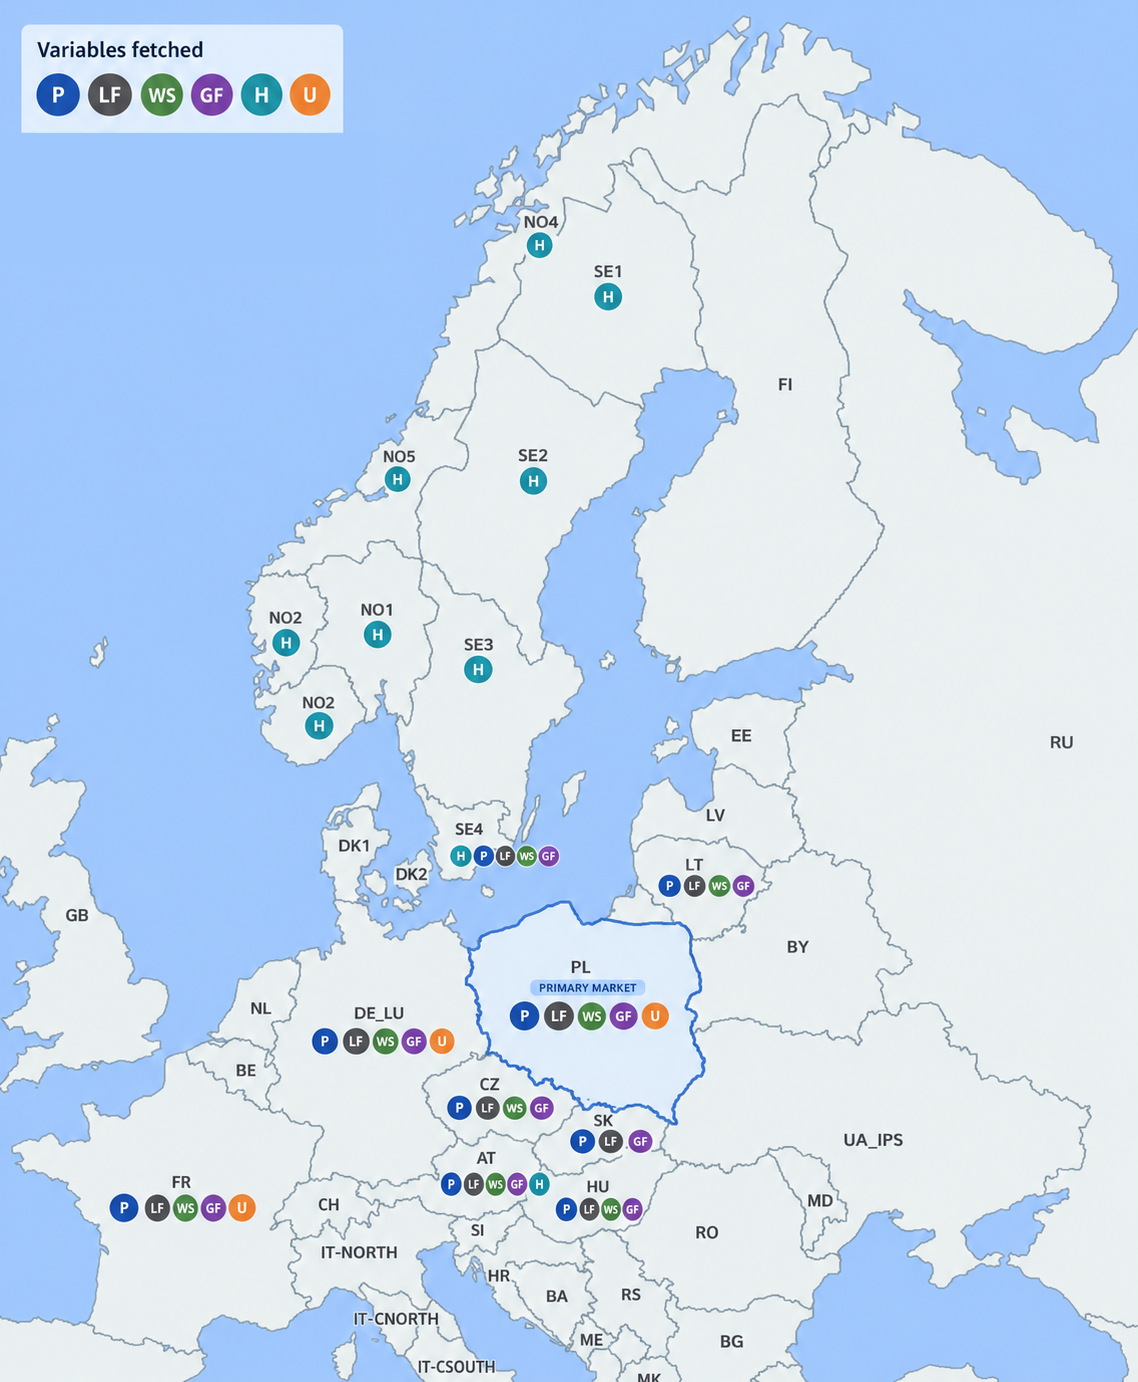

</div>

In [1]:
import pandas as pd
import sys
import logging

from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent))
from src.api.entsoe_api import EntsoeClient

from src.config import BASE_DIR, DATA_DIR, DOWNLOAD_START_DATE, DOWNLOAD_END_DATE

logging.basicConfig(level=logging.INFO)

In [2]:
client = EntsoeClient()

start_date = pd.Timestamp(DOWNLOAD_START_DATE, tz="Europe/Warsaw")
end_date = pd.Timestamp(DOWNLOAD_END_DATE, tz="Europe/Warsaw")

params = {"start_date": start_date, "end_date": end_date, "save_to_parquet": True}

bidding_zones_data = {
    "DE_LU": [
        "day_ahead_prices",
        "load_forecast",
        "generation_wind_solar_forecast",
        "generation_forecast",
        "generation_units_unavailability",
        "production_units_unavailability",
    ],
    "CZ": [
        "day_ahead_prices",
        "load_forecast",
        "generation_wind_solar_forecast",
        "generation_forecast",
    ],
    "SK": ["day_ahead_prices", "load_forecast", "generation_forecast"],
    "LT": [
        "day_ahead_prices",
        "load_forecast",
        "generation_wind_solar_forecast",
        "generation_forecast",
    ],
    "SE_4": [
        "day_ahead_prices",
        "load_forecast",
        "generation_wind_solar_forecast",
        "generation_forecast",
    ],
    "AT": [
        "day_ahead_prices",
        "load_forecast",
        "generation_wind_solar_forecast",
        "generation_forecast",
        "water_reservoirs_hydro_storage",
    ],
    "HU": [
        "day_ahead_prices",
        "load_forecast",
        "generation_wind_solar_forecast",
        "generation_forecast",
    ],
    "FR": [
        "day_ahead_prices",
        "load_forecast",
        "generation_wind_solar_forecast",
        "generation_forecast",
        "generation_units_unavailability",
        "production_units_unavailability",
    ],
    "NO": ["water_reservoirs_hydro_storage"],
    "SE": ["water_reservoirs_hydro_storage"],
}

In [ ]:
for bidding_zone in bidding_zones_data.keys():
    client.fetch(bidding_zone, datasets=bidding_zones_data[bidding_zone], **params)

In [ ]:
client.fetch("PL", fetch_all=True, **params)

In [3]:
bidding_zones = ["PL", *bidding_zones_data.keys()]
saved_count = {k: 0 for k in bidding_zones}

for bidding_zone in bidding_zones:
    data_dir = (
        DATA_DIR
        / "raw"
        / "entsoe"
        / bidding_zone
        / f"{start_date.strftime('%Y-%m-%d')}_{end_date.strftime('%Y-%m-%d')}"
    )

    file_paths = list(data_dir.iterdir())
    saved_count[bidding_zone] = len(file_paths)

    print(f"\n--- {bidding_zone} ({len(file_paths)} file/s) " + "-" * 30)

    for fp in file_paths:
        df = pd.read_parquet(fp)
        rel_path = fp.relative_to(BASE_DIR)
        print(f"  [FILE] {rel_path} | shape: {df.shape}")


--- PL (8 file/s) ------------------------------
  [FILE] data/raw/entsoe/PL/2022-12-01_2026-09-16/load.parquet | shape: (92633, 1)
  [FILE] data/raw/entsoe/PL/2022-12-01_2026-09-16/generation.parquet | shape: (92633, 15)
  [FILE] data/raw/entsoe/PL/2022-12-01_2026-09-16/load_forecast.parquet | shape: (92633, 1)
  [FILE] data/raw/entsoe/PL/2022-12-01_2026-09-16/day_ahead_prices.parquet | shape: (58485, 1)
  [FILE] data/raw/entsoe/PL/2022-12-01_2026-09-16/generation_wind_solar_forecast.parquet | shape: (92633, 3)
  [FILE] data/raw/entsoe/PL/2022-12-01_2026-09-16/generation_units_unavailability.parquet | shape: (20045, 18)
  [FILE] data/raw/entsoe/PL/2022-12-01_2026-09-16/production_units_unavailability.parquet | shape: (847, 18)
  [FILE] data/raw/entsoe/PL/2022-12-01_2026-09-16/generation_forecast.parquet | shape: (92633, 1)

--- DE_LU (6 file/s) ------------------------------
  [FILE] data/raw/entsoe/DE_LU/2022-12-01_2026-09-16/load_forecast.parquet | shape: (132948, 1)
  [FILE] data/